In [5]:
from bs4 import BeautifulSoup
import cloudscraper
import pandas as pd
from io import StringIO
import re
import time
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

In [ ]:
scraper = cloudscraper.create_scraper(
    browser={"browser": "chrome", "platform": "windows", "mobile": False}
)

In [ ]:
def extract_lineups(url, scraper):

    r = scraper.get(url)
    if r.status_code != 200:
        print(f"HTTP {r.status_code}: {url}")
        return None

    soup = BeautifulSoup(r.text, "lxml")

    table = soup.find("table", {"id": "stats_206d90db_summary"})
    if table is None:
        print(f"No lineup table: {url}")
        return None

    df = pd.read_html(StringIO(str(table)))[0]

    df.columns = [
        col[1] if col[0].startswith("Unnamed") else f"{col[0]}_{col[1]}"
        for col in df.columns
    ]

    match_id = re.search(r'/matches/([^/]+)/', url)
    match_id = match_id.group(1)
    df['match_id'] = match_id

    m = re.search(r"/matches/[^/]+/([^/]+)$", url)
    if not m:
        print(f"Invalid URL: {url}")
        return None

    slug = m.group(1)

    df.to_csv(
        f"/home/fjordan/Documentos/Proyectos/Personales/proyectos-Python/Analisis Lamine-Pedri/data/raw/lineups_{slug}.csv",
        index=False
    )

    return df


In [ ]:
score_fixtures_25_26 = pd.read_csv('/home/fjordan/Documentos/Proyectos/Personales/proyectos-Python/Analisis Lamine-Pedri/data/clean/score_fixtures_clean_2025-2026.csv')
score_fixtures_25_26.head()

,match_id,match_url,date,season,competition,opponent,home_away,goals_for,goals_against,xG_for,xG_against,posesion
0,64fa5074,https://fbref.com/en/matches/64fa5074/Mallorca...,2025-08-16,2025-2026,La Liga,Mallorca,Away,3.0,0.0,2.1,0.2,70.0
1,28628853,https://fbref.com/en/matches/28628853/Levante-...,2025-08-23,2025-2026,La Liga,Levante,Away,3.0,2.0,1.9,1.8,81.0
2,38c8e28a,https://fbref.com/en/matches/38c8e28a/Rayo-Val...,2025-08-31,2025-2026,La Liga,Rayo Vallecano,Away,1.0,1.0,1.8,1.8,56.0
3,2ed529d8,https://fbref.com/en/matches/2ed529d8/Barcelon...,2025-09-14,2025-2026,La Liga,Valencia,Home,6.0,0.0,3.9,0.1,71.0
4,53708b73,https://fbref.com/en/matches/53708b73/Newcastl...,2025-09-18,2025-2026,Champions Lg,eng Newcastle Utd,Away,2.0,1.0,1.1,1.2,63.0


In [ ]:
for url in score_fixtures_25_26['match_url']:
    extract_lineups(url, scraper)
    time.sleep(10)

No lineup table: https://fbref.com/en/stathead/matchup/teams/dee3bbc8/206d90db/Racing-Santander-vs-Barcelona-History
No lineup table: https://fbref.com/en/stathead/matchup/teams/e31d1cd9/206d90db/Real-Sociedad-vs-Barcelona-History
No lineup table: https://fbref.com/en/stathead/matchup/teams/206d90db/111cbfb1/Barcelona-vs-Slavia-Prague-History
No lineup table: https://fbref.com/en/stathead/matchup/teams/ab358912/206d90db/Oviedo-vs-Barcelona-History
No lineup table: https://fbref.com/en/stathead/matchup/teams/206d90db/18050b20/Barcelona-vs-FC-Copenhagen-History
No lineup table: https://fbref.com/en/stathead/matchup/teams/6c8b07df/206d90db/Elche-vs-Barcelona-History
No lineup table: https://fbref.com/en/stathead/matchup/teams/2aa12281/206d90db/Mallorca-vs-Barcelona-History
No lineup table: https://fbref.com/en/stathead/matchup/teams/9024a00a/206d90db/Girona-vs-Barcelona-History
No lineup table: https://fbref.com/en/stathead/matchup/teams/9800b6a1/206d90db/Levante-vs-Barcelona-History
No l

In [ ]:
score_fixtures_24_25 = pd.read_csv('/home/fjordan/Documentos/Proyectos/Personales/proyectos-Python/Analisis Lamine-Pedri/data/clean/score_fixtures_clean_2024-2025.csv')
score_fixtures_24_25.head()

,match_id,match_url,date,season,competition,opponent,home_away,goals_for,goals_against,xG_for,xG_against,posesion
0,6f0fac43,https://fbref.com/en/matches/6f0fac43/Valencia...,2024-08-17,2024-2025,La Liga,Valencia,Away,2,1,3.2,1.0,63
1,87bc9bba,https://fbref.com/en/matches/87bc9bba/Barcelon...,2024-08-24,2024-2025,La Liga,Athletic Club,Home,2,1,1.8,1.0,64
2,f8fc00c7,https://fbref.com/en/matches/f8fc00c7/Rayo-Val...,2024-08-27,2024-2025,La Liga,Rayo Vallecano,Away,2,1,1.4,0.4,64
3,3ed1b8ff,https://fbref.com/en/matches/3ed1b8ff/Barcelon...,2024-08-31,2024-2025,La Liga,Valladolid,Home,7,0,4.7,0.5,70
4,f166ffc9,https://fbref.com/en/matches/f166ffc9/Girona-B...,2024-09-15,2024-2025,La Liga,Girona,Away,4,1,1.9,1.3,55


In [ ]:
for url in score_fixtures_24_25['match_url']:
    extract_lineups(url, scraper)
    time.sleep(10)

In [6]:
def get_player_minutes(folder_path, players_target):
    folder_path = folder_path
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    players_target = players_target
    dfs = []

    for file in csv_files:
        df = pd.read_csv(file)
        df.columns = df.columns.str.lower()

        # Validar columnas necesarias
        required_cols = {"match_id", "player", "min"}
        if not required_cols.issubset(df.columns):
            continue

        # Asumimos un único match_id por CSV
        match_id = df["match_id"].iloc[0]

        # Filtrar jugadores objetivo
        df_filtered = df.loc[
            df["player"].isin(players_target),
            ["match_id", "player", "min"]
        ]

        # Crear dataframe base con ambos jugadores y min = 0
        base_df = pd.DataFrame({
            "match_id": match_id,
            "player": players_target,
            "min": 0
        })

        # Sobrescribir minutos si el jugador sí aparece en el CSV
        df_final = base_df.merge(
            df_filtered,
            on=["match_id", "player"],
            how="left",
            suffixes=("", "_real")
        )

        df_final["min"] = df_final["min_real"].fillna(df_final["min"])
        df_final = df_final[["match_id", "player", "min"]]

        dfs.append(df_final)

    # Concatenar todos los partidos
    df_player_minutes = pd.concat(dfs, ignore_index=True)

    # Asegurar tipo numérico
    df_player_minutes["min"] = pd.to_numeric(df_player_minutes["min"], errors="coerce")

    return df_player_minutes


In [7]:
folder_path = "/home/fjordan/Documentos/Proyectos/Personales/proyectos-Python/Analisis Lamine-Pedri/data/raw/lineups/2025-2026"
players_target = ["Pedri", "Lamine Yamal"]

df_player_minutes = get_player_minutes(folder_path, players_target)
df_player_minutes.head()

,match_id,player,min
0,28628853,Pedri,90.0
1,28628853,Lamine Yamal,90.0
2,2e731a54,Pedri,62.0
3,2e731a54,Lamine Yamal,90.0
4,23104cfb,Pedri,16.0


In [8]:
def unpivot_table(df):
    df = (
    df
        .pivot_table(
            index="match_id",
            columns="player",
            values="min",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    # limpiar nombres de columnas
    df.columns = (
    df.columns
        .astype(str)
        .str.strip()
        .str.replace("\xa0", "", regex=False)
    )

    # renombrar
    df = df.rename(columns={
    "Pedri": "pedri_min",
    "Lamine Yamal": "lamine_min"
    })


    df.columns.name = None #se agrega porque pivot / pivot_table casi siempre dejan columns.name 
    
    return df

In [9]:
df_player_minutes = unpivot_table(df_player_minutes)
df_player_minutes.head()

,match_id,lamine_min,pedri_min
0,12962665,89.0,0.0
1,28628853,90.0,90.0
2,01f948be,90.0,78.0
3,08d6715c,89.0,90.0
4,0c64b4c3,0.0,75.0


In [10]:
def get_xfor_posesion(path,df_1):
    df = pd.read_csv(path)

    # Normalizar columnas
    df.columns = df.columns.str.lower()
    df_1.columns = df_1.columns.str.lower()

    # ✅ QUEDARSE SOLO CON PARTIDOS REALES
    df = df[
    df["match_id"].notna() &
    (df["match_id"] != "")
    ]

    # Asegurar tipo
    df["match_id"] = df["match_id"].astype(str)
    df_1["match_id"] = df_1["match_id"].astype(str)

    df_final = (
    df
        .merge(df_1, on="match_id", how="left")
        [["match_id", "xg_for", "posesion", "lamine_min", "pedri_min"]]
    )

    df_final[["lamine_min", "pedri_min", "xg_for"]] = df_final[
    ["lamine_min", "pedri_min", "xg_for"]
    ].fillna(0)
    
    return df_final

In [11]:
path = "/home/fjordan/Documentos/Proyectos/Personales/proyectos-Python/Analisis Lamine-Pedri/data/clean/score_fixtures_clean_2025-2026.csv"

df_final = get_xfor_posesion(path,df_player_minutes )
df_final

,match_id,xg_for,posesion,lamine_min,pedri_min
0,64fa5074,2.1,70.0,90.0,90.0
1,28628853,1.9,81.0,90.0,90.0
2,38c8e28a,1.8,56.0,90.0,90.0
3,2ed529d8,3.9,71.0,0.0,80.0
4,53708b73,1.1,63.0,0.0,90.0
5,0c64b4c3,2.0,70.0,0.0,75.0
6,fa8efe81,2.0,78.0,0.0,89.0
7,65ee8953,2.2,74.0,33.0,89.0
8,01f948be,1.3,47.0,90.0,78.0
9,bc939aab,2.2,60.0,0.0,90.0


In [12]:
def add_columns(df):
    df["lamine_played"] = (df["lamine_min"] > 0).astype(int)
    df["pedri_played"] = (df["pedri_min"] > 0).astype(int)

    df["lamine_60"] = (df["lamine_min"] >= 60).astype(int)
    df["pedri_60"] = (df["pedri_min"] >= 60).astype(int)
    df = df[df['xg_for']!=0]
    return df


In [13]:
df_final = add_columns(df_final)
df_final

,match_id,xg_for,posesion,lamine_min,pedri_min,lamine_played,pedri_played,lamine_60,pedri_60
0,64fa5074,2.1,70.0,90.0,90.0,1,1,1,1
1,28628853,1.9,81.0,90.0,90.0,1,1,1,1
2,38c8e28a,1.8,56.0,90.0,90.0,1,1,1,1
3,2ed529d8,3.9,71.0,0.0,80.0,0,1,0,1
4,53708b73,1.1,63.0,0.0,90.0,0,1,0,1
5,0c64b4c3,2.0,70.0,0.0,75.0,0,1,0,1
6,fa8efe81,2.0,78.0,0.0,89.0,0,1,0,1
7,65ee8953,2.2,74.0,33.0,89.0,1,1,0,1
8,01f948be,1.3,47.0,90.0,78.0,1,1,1,1
9,bc939aab,2.2,60.0,0.0,90.0,0,1,0,1


df_pedri_on
→ filas donde pedri_60 == 1

In [14]:
def build_scenario_df(
    df,
    scenarios,
    metrics=None
):
    """
    Construye un DataFrame resumen por escenarios a partir de masks booleanas.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame base.
    scenarios : dict
        {scenario_name: boolean_mask}
    metrics : dict, optional
        {output_col: source_col}

    Returns
    -------
    pd.DataFrame
    """

    if metrics is None:
        metrics = {
            "xg_for_media": "xg_for",
            "posesion_for_media": "posesion"
        }

    rows = []

    for name, mask in scenarios.items():
        sub = df.loc[mask]

        row = {
            "scenario": name,
            "partidos": len(sub)
        }

        for out_col, src_col in metrics.items():
            row[out_col] = sub[src_col].mean()

        rows.append(row)

    return pd.DataFrame(rows)


In [15]:
scenarios = {
    "pedri_on": df_final["pedri_60"] == 1,
    "pedri_off": df_final["pedri_60"] == 0,
    "lamine_on": df_final["lamine_60"] == 1,
    "lamine_off": df_final["lamine_60"] == 0,
    "both_on": (df_final["pedri_60"] == 1) & (df_final["lamine_60"] == 1)
}


In [16]:
scenario_df = build_scenario_df(df_final, scenarios)
scenario_df

,scenario,partidos,xg_for_media,posesion_for_media
0,pedri_on,17,2.123529,67.529412
1,pedri_off,8,2.112500,63.750000
2,lamine_on,19,2.084211,65.368421
3,lamine_off,6,2.233333,69.333333
4,both_on,11,2.063636,66.545455


In [29]:
# Aseguramos orden lógico de escenarios
order = [
    "pedri_on",
    "pedri_off",
    "lamine_on",
    "lamine_off",
    "both_on"
]

# Etiquetas legibles
label_map = {
    "pedri_on": "Pedri ON",
    "pedri_off": "Pedri OFF",
    "lamine_on": "Lamine ON",
    "lamine_off": "Lamine OFF",
    "both_on": "Ambos ON"
}

In [30]:
def prepare_scenario_plot_df(
    df,
    order,
    label_map,
    scenario_col="scenario"
):
    """
    Mueve la columna scenario al índice, Selecciona exactamente esas filas en ese orden, devuelve scenario a columna y el indice a 0,1,2
    set_index("scenario")   # usar scenario como “llave”
    .loc[order]             # reordenar filas según esa llave
    .reset_index()          # devolver scenario como columna normal
    """
    df_plot = (
        df
        .set_index(scenario_col)
        .loc[order]
        .reset_index()
    )
    #“Para cada escenario, busca su etiqueta legible y colócala en una nueva columna”("pedri_on" → "Pedri ON")
    df_plot["label"] = df_plot[scenario_col].map(label_map)

    return df_plot


In [31]:
df_plot = prepare_scenario_plot_df(
    scenario_df,
    order=order,
    label_map=label_map
)
df_plot

,scenario,partidos,xg_for_media,posesion_for_media,label
0,pedri_on,17,2.123529,67.529412,Pedri ON
1,pedri_off,8,2.112500,63.750000,Pedri OFF
2,lamine_on,19,2.084211,65.368421,Lamine ON
3,lamine_off,6,2.233333,69.333333,Lamine OFF
4,both_on,11,2.063636,66.545455,Ambos ON


In [32]:
colors = [
    "#2E86AB",  # Pedri ON (azul)
    "#9FC9E3",  # Pedri OFF (azul claro)
    "#F2C94C",  # Lamine ON (amarillo)
    "#F7D774",  # Lamine OFF (amarillo claro)
    "#1B3B6F"   # Ambos ON (azul oscuro)
]


In [ ]:
def bar_plot(
    labels,
    values,
    ylabel,
    *,
    #Todos los parámetros que vienen después SOLO pueden pasarse por nombre (keyword-only)
    #(value_type, colors, filename)tienen valores por defecto y controlan comportamiento, no son obligatorios 
    value_type="xg",   # "xg" o "percent"
    colors=None,
    filename=None
):
    fig, ax = plt.subplots(figsize=(12, 7))

    # Fondo transparente
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    # Barras
    bars = ax.bar(
        labels,
        values,
        color=colors,
        width=0.6
    )

    # Configuración según tipo de valor
    if value_type == "xg":
        offset = 0.0005
        fmt = "{:.2f}"
        ylim = (values.min() - 0.1, values.max() + 0.1)
    else:
        offset = 0.015
        fmt = "{:.1f}%"
        ylim = (60, 70)

    # Labels encima de las barras
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=12,
            color="white",
            fontweight="semibold"
        )

    # Ejes
    ax.set_ylabel(ylabel, fontsize=12, color="white")
    ax.set_ylim(*ylim)#* unpacking de una tupla(60,70)

    ax.tick_params(axis="x", colors="white", labelsize=11)
    ax.tick_params(axis="y", colors="white", labelsize=11)

    if value_type == "percent":
        ax.set_yticklabels([f"{int(tick)}%" for tick in ax.get_yticks()])

    # Grid
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)

    # Quitar spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Nota
    fig.text(
        0.01,
        0.0005,
        "*Escenarios definidos por disponibilidad ≥ 60’",
        color="#CBD5E1",
        fontsize=9
    )

    # Guardar
    plt.tight_layout()
    if filename:
        plt.savefig(
            filename,
            dpi=300,
            transparent=True,
            bbox_inches="tight"
        )

    plt.show()

In [49]:
label=df_plot["label"]
value=df_plot["xg_for_media"]
ylabel = "xG a favor (media por partido)"

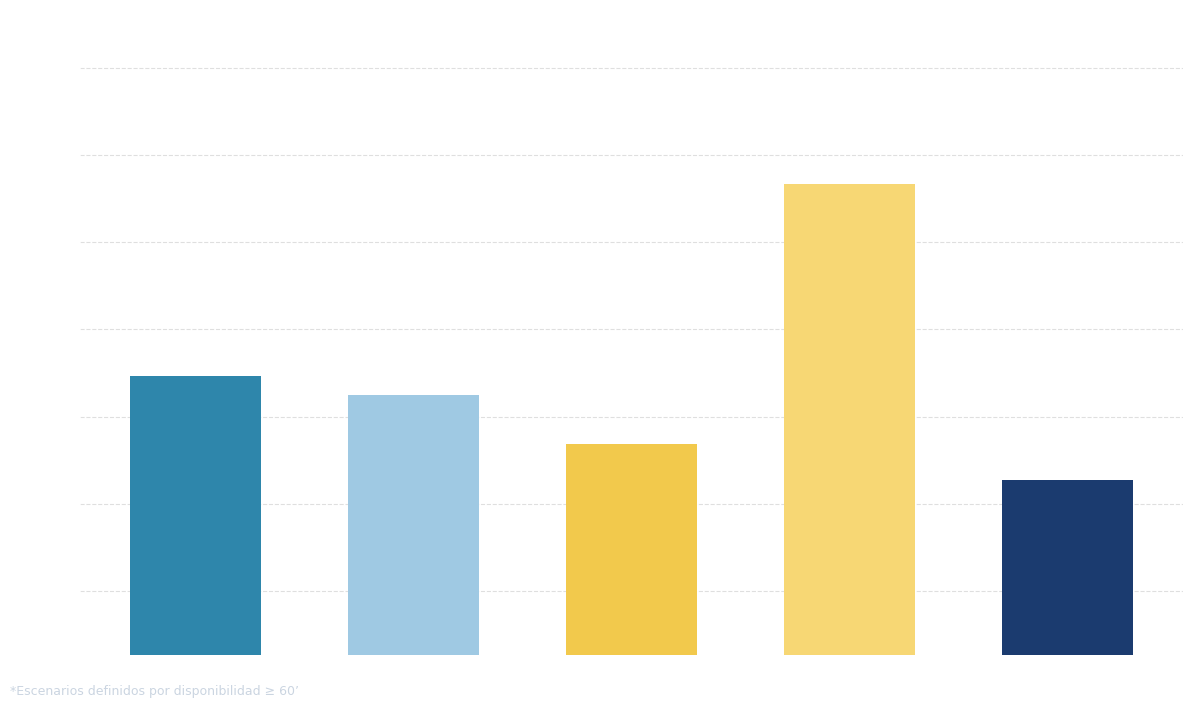

In [50]:
bar_plot(
    labels=label,
    values=value,
    ylabel=ylabel,
    value_type="xg",
    colors=colors,
    filename="impacto_xg_escenarios.png"
)



In [51]:
label = df_plot["label"]
value = df_plot["posesion_for_media"]
ylabel = "Posesión media (%)"

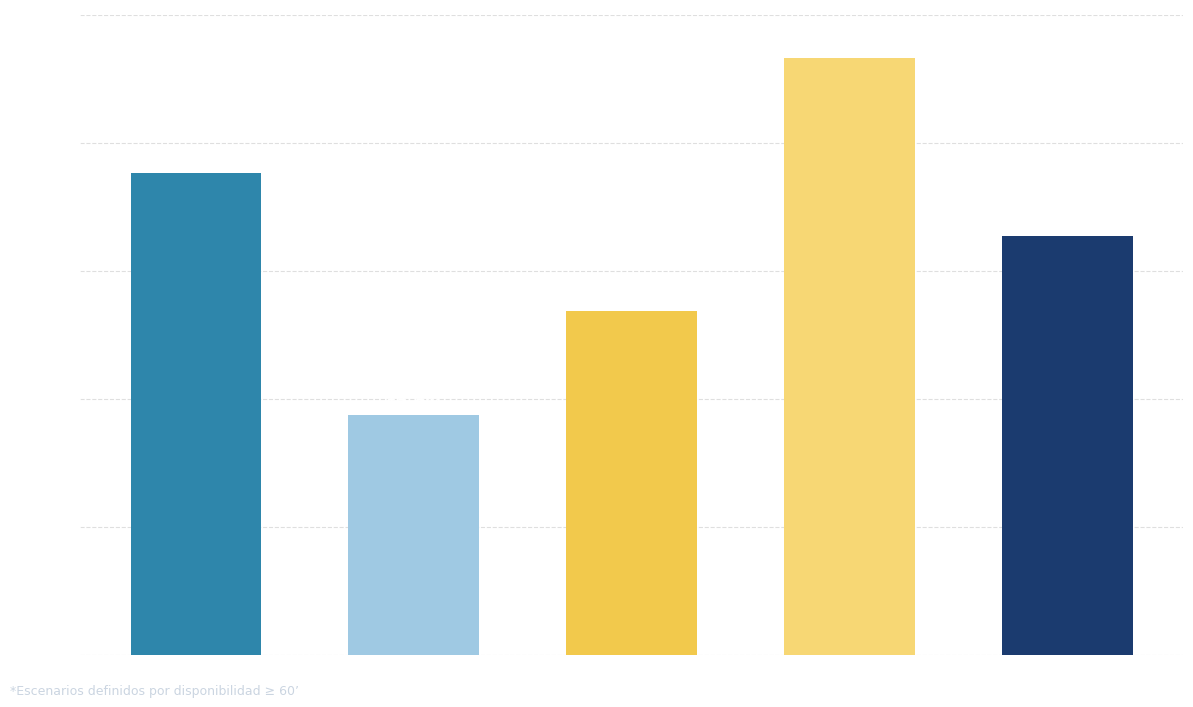

In [52]:
bar_plot(
    labels=label,
    values=value,
    ylabel=ylabel,
    value_type="percent",
    colors=colors,
    filename="impacto_posesion_escenarios.png"
)